In [20]:
import torch
import json
import os

from data.ae_dataset import AEDataset
from torch import linalg as LA
import numpy as np
from matplotlib.pyplot import plot
from tqdm import tqdm
from PIL import Image, ImageDraw, ImageFont

# Display norm

In [8]:
rec_seq = torch.load("model_outputs/rec_seq_0724_204251_v9.pt")   # [10377, 10, 512]

In [9]:
all_norm_list = []
for seq in rec_seq:
    # seq: [10, 512]
    norm_list = []
    for emb in seq:
        # emb: [512]
        norm_list.append(LA.norm(emb).item())
    all_norm_list.append(norm_list)

In [28]:
len(all_norm_list)

10377

In [7]:
all_norm_list[0]

[0.9535671472549438,
 0.9414432048797607,
 0.020499056205153465,
 0.571505069732666,
 0.6649578213691711,
 0.6469458937644958,
 0.7069915533065796,
 0.6859124302864075,
 0.7175210118293762,
 0.7258670926094055]

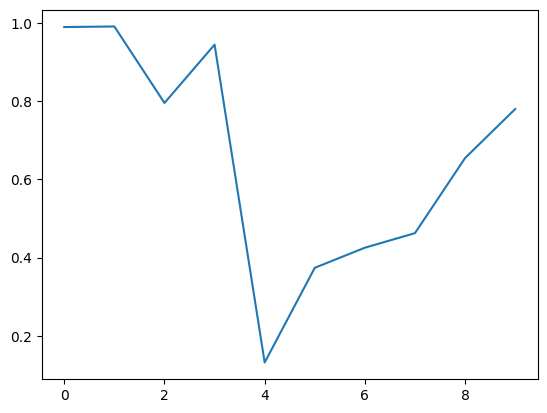

In [24]:
plot(range(10), all_norm_list[1230])

# Find closest parts embedding

In [2]:
# find the pad for ori, compute the 'mask'
eps = 0.2
threshold = 0.5

In [3]:
all_emb_path = os.path.join("./processed_data", "mean_pooled_emb.pt")
all_emb = torch.load(all_emb_path)   # [141245, 512]

In [4]:
all_md_path = os.path.join("./processed_data", "emb_idx_filtered.json")
with open(all_md_path, 'r') as fp:
    all_md = json.load(fp)   # .shape[0]=141245

In [15]:
def find_closest(emb):
    delta = all_emb - emb
#     print(delta.shape)
    dist = LA.norm(delta, dim=1)
#     print(dist.shape)
    idx = dist.argmin()
#     print(dist[:10])
#     print(idx)
#     print(dist[idx])
    
    return idx.item()

In [16]:
all_closest_emb_list = []
for i, seq in tqdm(enumerate(rec_seq[:10, :, :])):
    closest_emb_list = []
    for j, rec_emb in enumerate(seq):
        if all_norm_list[i][j] < eps:
            break
        closest_emb_idx = find_closest(rec_emb)
        closest_emb_list.append(closest_emb_idx)
    all_closest_emb_list.append(closest_emb_list)

10it [00:03,  2.86it/s]


In [17]:
all_closest_emb_list

[[125521, 131605],
 [19912, 77759, 138328],
 [38839, 3685, 375],
 [64382, 66912],
 [51626, 117248],
 [4876, 125033, 71010, 4079],
 [80816, 33019, 23827, 6252, 101127, 101127, 50414, 50414, 128149, 50434],
 [48943, 36612],
 [44250, 50834],
 [99272, 129227, 3874, 67912]]

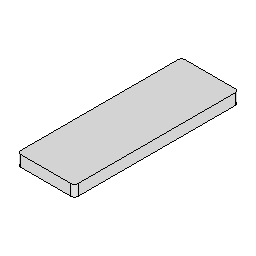

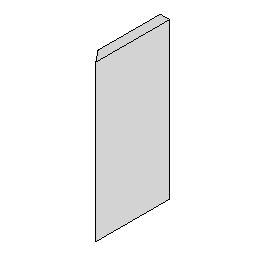

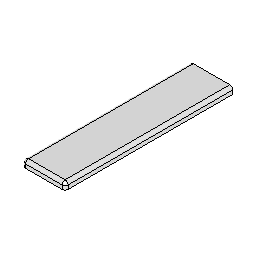

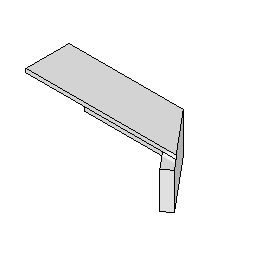

In [34]:
for img_idx in all_closest_emb_list[9]:
    img_path = f'./raw_data/00/{all_md[img_idx]}_0000.png'
    img = Image.open(img_path)
    img.show()